In [1]:
import duckdb

# connect to your database
con = duckdb.connect('../data/warehouse_new.duckdb')  # adjust path if needed

In [2]:
data = con.sql("SELECT * FROM merged_sales_customers_clean").fetchdf()
data

,meterid,customer_no,od_date,ocd_paymoney,ocd_energy,ocd_cash_received,utility,tariff_type
0,11010734551,501001396162,2014-04-26,10.00,32.30,10.00,Techiman,Residential
1,11010734551,501001396162,2014-10-08,50.00,137.15,50.00,Techiman,Residential
2,11010734551,501001396162,2014-03-29,30.00,87.29,30.00,Techiman,Residential
3,11010734551,501001396162,2014-06-27,50.00,157.92,50.00,Techiman,Residential
4,11010734551,501001396162,2014-09-23,50.00,124.44,50.00,Techiman,Residential
...,...,...,...,...,...,...,...,...
5100343,19018165451,504001432116,2020-05-05,19.25,50.00,1.00,Akumadan,Residential
5100344,19018165451,504001432116,2020-04-06,18.65,50.00,18.65,Akumadan,Residential
5100345,19018169951,501001421723,2020-06-01,59.33,100.60,40.00,Techiman,Residential
5100346,19018169951,501001421723,2020-06-26,15.00,21.80,15.00,Techiman,Residential


In [3]:
import pandas as pd

# ensure datetime
data['od_date'] = pd.to_datetime(data['od_date'])

# year-month key
data['year_month'] = data['od_date'].dt.to_period('M')

# group
monthly = (
    data.sort_values('od_date')  # so "first" picks earliest date
        .groupby(['meterid', 'year_month'], as_index=False)
        .agg({
            'od_date': 'first',               # earliest date in that month
            'ocd_paymoney': 'sum',
            'ocd_energy': 'sum',
            'ocd_cash_received': 'sum',
            'customer_no': 'first',
            'utility': 'first',
            'tariff_type': 'first'
        })
)

monthly


,meterid,year_month,od_date,ocd_paymoney,ocd_energy,ocd_cash_received,customer_no,utility,tariff_type
0,10000000000,2018-04,2018-04-25,100.00,174.20,100.0,502001426719,Wenchi,Residential
1,10010284581,2012-10,2012-10-25,6.00,30.14,6.0,501001387012,Techiman,Residential
2,11010003761,2012-12,2012-12-22,22.00,130.80,22.0,501001392093,Techiman,Residential
3,11010003761,2013-02,2013-02-15,12.00,64.54,12.0,501001392093,Techiman,Residential
4,11010003761,2013-03,2013-03-09,23.00,156.48,23.0,501001392093,Techiman,Residential
...,...,...,...,...,...,...,...,...,...
2800293,19018242171,2020-05,2020-05-09,40.00,26.00,15.0,513001459644,Busunya,Non Residential
2800294,19018242171,2020-06,2020-06-15,40.00,26.00,15.0,513001459644,Busunya,Non Residential
2800295,19018242171,2020-07,2020-07-24,35.00,20.90,10.0,513001459644,Busunya,Non Residential
2800296,2081300919,2015-11,2015-11-26,50.00,65.14,50.0,502001423657,Wenchi,Non Residential


In [4]:
import numpy as np

df = monthly.copy()

# convert to timestamp
df["od_date"] = pd.to_datetime(df["od_date"])
df = df.sort_values(["meterid", "od_date"]).reset_index(drop=True)

# calendar + seasonality
df["year"] = df["od_date"].dt.year
df["month"] = df["od_date"].dt.month
df["quarter"] = df["od_date"].dt.quarter
df["sin_month"] = np.sin(2*np.pi*df["month"]/12)
df["cos_month"] = np.cos(2*np.pi*df["month"]/12)

# encode utility / tariff
df["utility"] = df["utility"].astype("category").cat.codes
df["tariff_type"] = df["tariff_type"].astype("category").cat.codes


In [5]:
df

,meterid,year_month,od_date,ocd_paymoney,ocd_energy,ocd_cash_received,customer_no,utility,tariff_type,year,month,quarter,sin_month,cos_month
0,10000000000,2018-04,2018-04-25,100.00,174.20,100.0,502001426719,13,2,2018,4,2,8.660254e-01,-5.000000e-01
1,10010284581,2012-10,2012-10-25,6.00,30.14,6.0,501001387012,12,2,2012,10,4,-8.660254e-01,5.000000e-01
2,11010003761,2012-12,2012-12-22,22.00,130.80,22.0,501001392093,12,2,2012,12,4,-2.449294e-16,1.000000e+00
3,11010003761,2013-02,2013-02-15,12.00,64.54,12.0,501001392093,12,2,2013,2,1,8.660254e-01,5.000000e-01
4,11010003761,2013-03,2013-03-09,23.00,156.48,23.0,501001392093,12,2,2013,3,1,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2800293,19018242171,2020-05,2020-05-09,40.00,26.00,15.0,513001459644,4,1,2020,5,2,5.000000e-01,-8.660254e-01
2800294,19018242171,2020-06,2020-06-15,40.00,26.00,15.0,513001459644,4,1,2020,6,2,1.224647e-16,-1.000000e+00
2800295,19018242171,2020-07,2020-07-24,35.00,20.90,10.0,513001459644,4,1,2020,7,3,-5.000000e-01,-8.660254e-01
2800296,2081300919,2015-11,2015-11-26,50.00,65.14,50.0,502001423657,13,1,2015,11,4,-5.000000e-01,8.660254e-01


In [7]:
lags = [1, 2, 3, 6, 12]

for col in ["ocd_paymoney", "ocd_energy", "ocd_cash_received"]:
    for lag in lags:
        df[f"{col}_lag{lag}"] = (
            df.groupby("meterid")[col].shift(lag)
        )


In [8]:
windows = [3, 6, 12]

for col in ["ocd_paymoney", "ocd_energy", "ocd_cash_received"]:
    for w in windows:
        df[f"{col}_roll{w}"] = (
            df.groupby("meterid")[col]
              .shift(1)
              .rolling(w)
              .mean()
              .reset_index(level=0, drop=True)
        )


In [9]:
# differences
df["energy_diff"] = df.groupby("meterid")["ocd_energy"].diff()
df["paymoney_diff"] = df.groupby("meterid")["ocd_paymoney"].diff()
df["cash_diff"] = df.groupby("meterid")["ocd_cash_received"].diff()

# ratios
df["pay_ratio"] = df["ocd_paymoney"] / (df["ocd_energy"] + 1e-6)
df["collection_eff"] = df["ocd_cash_received"] / (df["ocd_paymoney"] + 1e-6)

# interactions
df["energy_tariff"] = df["ocd_energy"] * df["tariff_type"]
df["pay_tariff"] = df["ocd_paymoney"] * df["tariff_type"]


In [10]:
for h in range(1, 13):
    df[f"paymoney_h{h}"] = df.groupby("meterid")["ocd_paymoney"].shift(-h)
    df[f"energy_h{h}"]   = df.groupby("meterid")["ocd_energy"].shift(-h)
    df[f"cash_h{h}"]     = df.groupby("meterid")["ocd_cash_received"].shift(-h)


In [11]:
df

,meterid,year_month,od_date,ocd_paymoney,ocd_energy,ocd_cash_received,customer_no,utility,tariff_type,year,...,cash_h9,paymoney_h10,energy_h10,cash_h10,paymoney_h11,energy_h11,cash_h11,paymoney_h12,energy_h12,cash_h12
0,10000000000,2018-04,2018-04-25,100.00,174.20,100.0,502001426719,13,2,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10010284581,2012-10,2012-10-25,6.00,30.14,6.0,501001387012,12,2,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11010003761,2012-12,2012-12-22,22.00,130.80,22.0,501001392093,12,2,2012,...,66.0,55.00,166.62,55.0,60.00,182.71,60.0,65.43,200.20,63.0
3,11010003761,2013-02,2013-02-15,12.00,64.54,12.0,501001392093,12,2,2013,...,55.0,60.00,182.71,60.0,65.43,200.20,63.0,65.50,200.42,65.5
4,11010003761,2013-03,2013-03-09,23.00,156.48,23.0,501001392093,12,2,2013,...,60.0,65.43,200.20,63.0,65.50,200.42,65.5,66.00,202.03,66.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2800293,19018242171,2020-05,2020-05-09,40.00,26.00,15.0,513001459644,4,1,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2800294,19018242171,2020-06,2020-06-15,40.00,26.00,15.0,513001459644,4,1,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2800295,19018242171,2020-07,2020-07-24,35.00,20.90,10.0,513001459644,4,1,2020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2800296,2081300919,2015-11,2015-11-26,50.00,65.14,50.0,502001423657,13,1,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df = df.dropna().reset_index(drop=True)
df

,meterid,year_month,od_date,ocd_paymoney,ocd_energy,ocd_cash_received,customer_no,utility,tariff_type,year,...,cash_h9,paymoney_h10,energy_h10,cash_h10,paymoney_h11,energy_h11,cash_h11,paymoney_h12,energy_h12,cash_h12
0,11010003761,2014-04,2014-04-04,65.43,200.20,63.0,501001392093,12,2,2014,...,80.00,99.4,252.96,99.4,79.4,200.00,79.4,110.8,275.02,110.8
1,11010003761,2014-05,2014-05-06,65.50,200.42,65.5,501001392093,12,2,2014,...,99.40,79.4,200.00,79.4,110.8,275.02,110.8,82.0,200.87,82.0
2,11010003761,2014-06,2014-06-07,66.00,202.03,66.0,501001392093,12,2,2014,...,79.40,110.8,275.02,110.8,82.0,200.87,82.0,81.7,200.10,81.7
3,11010003761,2014-07,2014-07-06,74.10,200.00,74.1,501001392093,12,2,2014,...,110.80,82.0,200.87,82.0,81.7,200.10,81.7,81.7,200.10,81.7
4,11010003761,2014-08,2014-08-08,74.10,200.00,74.1,501001392093,12,2,2014,...,82.00,81.7,200.10,81.7,81.7,200.10,81.7,88.7,218.12,88.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1327123,17016386901,2019-07,2019-07-01,170.00,276.30,170.0,501001416562,12,2,2019,...,98.65,140.0,218.00,80.0,120.0,188.90,60.0,100.0,159.80,40.0
1327124,17016386901,2019-08,2019-08-02,84.00,143.70,84.0,501001416562,12,2,2019,...,80.00,120.0,188.90,60.0,100.0,159.80,40.0,70.0,116.10,70.0
1327125,17016387001,2019-07,2019-07-04,105.00,176.20,105.0,501001417052,12,2,2019,...,200.00,240.0,349.00,130.0,210.0,315.40,100.0,210.0,315.40,100.0
1327126,17016387001,2019-08,2019-08-01,160.00,261.00,160.0,501001417052,12,2,2019,...,130.00,210.0,315.40,100.0,210.0,315.40,100.0,50.0,87.00,50.0


In [13]:
split_idx = int(len(df) * 0.85)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]


In [14]:
targets = {
    "paymoney": [f"paymoney_h{h}" for h in range(1, 13)],
    "energy":   [f"energy_h{h}"   for h in range(1, 13)],
    "cash":     [f"cash_h{h}"     for h in range(1, 13)],
}

exclude_cols = (
    ["meterid", "od_date", "year_month", "customer_no"] +
    targets["paymoney"] + targets["energy"] + targets["cash"]
)

feature_cols = [c for c in df.columns if c not in exclude_cols]


In [15]:
feature_cols

['ocd_paymoney',
 'ocd_energy',
 'ocd_cash_received',
 'utility',
 'tariff_type',
 'year',
 'month',
 'quarter',
 'sin_month',
 'cos_month',
 'ocd_paymoney_lag1',
 'ocd_paymoney_lag2',
 'ocd_paymoney_lag3',
 'ocd_paymoney_lag6',
 'ocd_paymoney_lag12',
 'ocd_energy_lag1',
 'ocd_energy_lag2',
 'ocd_energy_lag3',
 'ocd_energy_lag6',
 'ocd_energy_lag12',
 'ocd_cash_received_lag1',
 'ocd_cash_received_lag2',
 'ocd_cash_received_lag3',
 'ocd_cash_received_lag6',
 'ocd_cash_received_lag12',
 'ocd_paymoney_roll3',
 'ocd_paymoney_roll6',
 'ocd_paymoney_roll12',
 'ocd_energy_roll3',
 'ocd_energy_roll6',
 'ocd_energy_roll12',
 'ocd_cash_received_roll3',
 'ocd_cash_received_roll6',
 'ocd_cash_received_roll12',
 'energy_diff',
 'paymoney_diff',
 'cash_diff',
 'pay_ratio',
 'collection_eff',
 'energy_tariff',
 'pay_tariff']

In [16]:
targets

{'paymoney': ['paymoney_h1',
  'paymoney_h2',
  'paymoney_h3',
  'paymoney_h4',
  'paymoney_h5',
  'paymoney_h6',
  'paymoney_h7',
  'paymoney_h8',
  'paymoney_h9',
  'paymoney_h10',
  'paymoney_h11',
  'paymoney_h12'],
 'energy': ['energy_h1',
  'energy_h2',
  'energy_h3',
  'energy_h4',
  'energy_h5',
  'energy_h6',
  'energy_h7',
  'energy_h8',
  'energy_h9',
  'energy_h10',
  'energy_h11',
  'energy_h12'],
 'cash': ['cash_h1',
  'cash_h2',
  'cash_h3',
  'cash_h4',
  'cash_h5',
  'cash_h6',
  'cash_h7',
  'cash_h8',
  'cash_h9',
  'cash_h10',
  'cash_h11',
  'cash_h12']}

In [17]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import lightgbm as lgb

tscv = TimeSeriesSplit(n_splits=3)

param_dist = {
    "num_leaves":       [31, 63, 127, 255],
    "learning_rate":    [0.01, 0.02, 0.05, 0.1],
    "min_child_samples":[20, 40, 80, 160],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators":     [300, 500, 800]
}


In [20]:
def train_group(target_list, name):
    models = {}
    
    for h, target in enumerate(target_list, start=1):
        print(f"Training {name} horizon {h}/12...")

        X_train = train_df[feature_cols]
        y_train = train_df[target]

        model = lgb.LGBMRegressor()

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist,
            n_iter=10,
            scoring="neg_mean_absolute_error",
            cv=tscv,
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train, y_train)
        models[h] = search.best_estimator_

    return models


In [21]:
models_paymoney = train_group(targets["paymoney"], "paymoney")
models_energy   = train_group(targets["energy"],   "energy")
models_cash     = train_group(targets["cash"],     "cash")


Training paymoney horizon 1/12...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8736
[LightGBM] [Info] Number of data points in the train set: 1128058, number of used features: 41
[LightGBM] [Info] Start training from score 107.367286
Training paymoney horizon 2/12...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8736
[LightGBM] [Info] Number of data points in the train set: 1128058, number of used features: 41
[LightGBM] [Info] Start training from score 1

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_group(models, target_list, name):
    X_test = test_df[feature_cols]
    results = []

    for h, target_col in enumerate(target_list, start=1):
        model = models[h]
        y_true = test_df[target_col].values
        y_pred = model.predict(X_test)

        results.append({
            "target": name,
            "horizon": h,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": rmse(y_true, y_pred),
            "R2": r2_score(y_true, y_pred),
        })

    return pd.DataFrame(results)


In [26]:
eval_paymoney = evaluate_group(models_paymoney, targets["paymoney"], "paymoney")
eval_energy   = evaluate_group(models_energy,   targets["energy"],   "energy")
eval_cash     = evaluate_group(models_cash,     targets["cash"],     "cash")

eval_all = pd.concat([eval_paymoney, eval_energy, eval_cash], ignore_index=True)
eval_all


,target,horizon,MAE,RMSE,R2
0,paymoney,1,23.766721,132.001280,0.811634
1,paymoney,2,25.362111,113.906966,0.857137
2,paymoney,3,27.518681,123.646326,0.833828
3,paymoney,4,29.021650,127.432974,0.825426
4,paymoney,5,30.380550,133.657946,0.812305
5,paymoney,6,32.567546,139.196909,0.804786
6,paymoney,7,33.054378,146.763984,0.793143
7,paymoney,8,35.446830,154.264202,0.780467
8,paymoney,9,35.886757,154.538495,0.786009
9,paymoney,10,37.527081,154.834787,0.787899


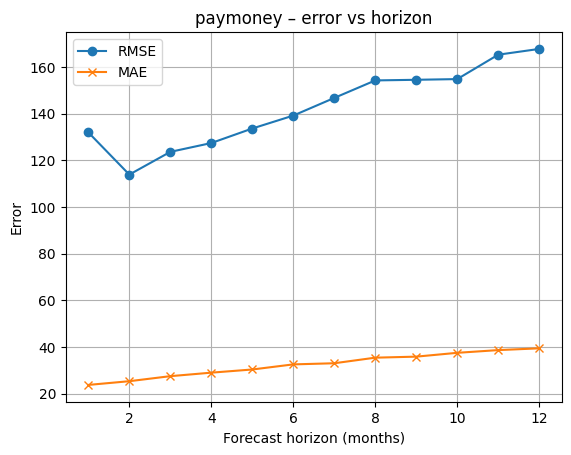

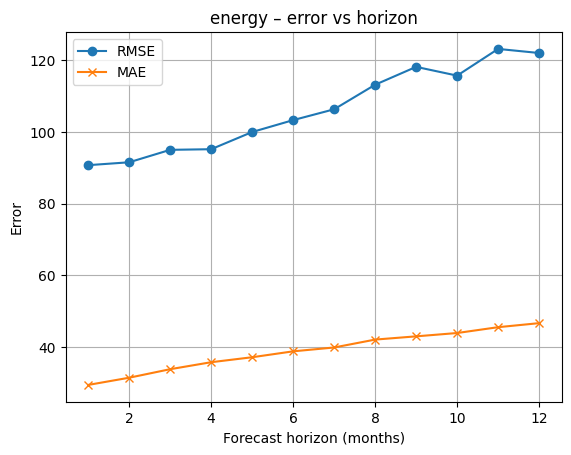

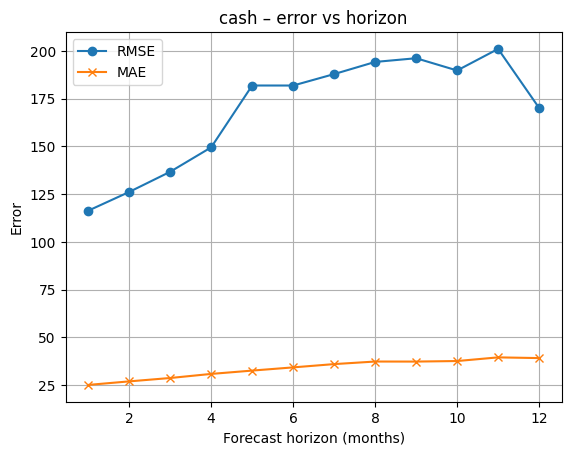

In [27]:
import matplotlib.pyplot as plt

def plot_errors(df_eval, target_name):
    sub = df_eval[df_eval["target"] == target_name].sort_values("horizon")

    plt.plot(sub["horizon"], sub["RMSE"], marker="o", label="RMSE")
    plt.plot(sub["horizon"], sub["MAE"],  marker="x", label="MAE")
    plt.xlabel("Forecast horizon (months)")
    plt.ylabel("Error")
    plt.title(f"{target_name} – error vs horizon")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_errors(eval_all, "paymoney")
plot_errors(eval_all, "energy")
plot_errors(eval_all, "cash")


In [28]:
meter = test_df["meterid"].sample(1).iloc[0]   # random meterid
h = 3                                          # forecast horizon you want to inspect (1..12)

print("MeterID:", meter)


MeterID: 16014807141


In [29]:
df_m = test_df[test_df["meterid"] == meter].copy().sort_values("od_date")


In [34]:
model = models_cash[h]

X_m = df_m[feature_cols]
y_true = df_m[f"cash_h{h}"].values
y_pred = model.predict(X_m)


In [36]:
model = models_paymoney[h]
y_true = df_m[f"paymoney_h{h}"].values


In [32]:
model = models_energy[h]
y_true = df_m[f"energy_h{h}"].values


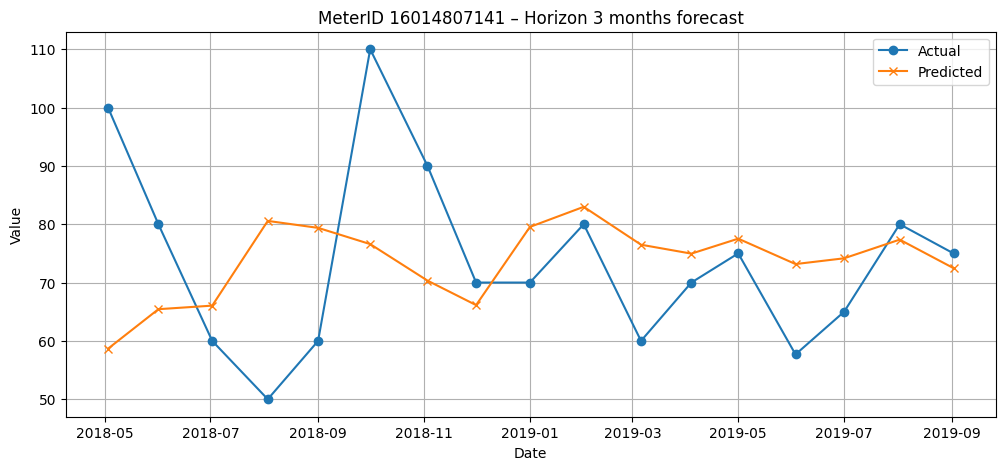

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_m["od_date"], y_true, label="Actual", marker="o")
plt.plot(df_m["od_date"], y_pred, label="Predicted", marker="x")

plt.title(f"MeterID {meter} – Horizon {h} months forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()


In [44]:
def refit_group_from_best(cv_models, data, target_list, name):
    """
    cv_models: dict {h: fitted best_estimator_ from CV on train_df}
    data: full df (train+test)
    target_list: list of target columns
    name: just for printing
    """
    X_full = data[feature_cols]
    models_full = {}

    for h, target in enumerate(target_list, start=1):
        print(f"Refitting {name} horizon {h}/12 on FULL data ({len(data)} rows)...")

        y_full = data[target]

        best = cv_models[h]
        best_params = best.get_params()

        # safety: remove CV-specific stuff if any
        best_params.pop("n_jobs", None)

        final_model = lgb.LGBMRegressor(**best_params)
        final_model.fit(X_full, y_full)
        models_full[h] = final_model

    return models_full


In [46]:
models_paymoney_full = refit_group_from_best(models_paymoney, df, targets["paymoney"], "paymoney")
models_energy_full   = refit_group_from_best(models_energy,   df, targets["energy"],   "energy")
models_cash_full     = refit_group_from_best(models_cash,     df, targets["cash"],     "cash")

Refitting paymoney horizon 1/12 on FULL data (1327128 rows)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8736
[LightGBM] [Info] Number of data points in the train set: 1327128, number of used features: 41
[LightGBM] [Info] Start training from score 105.027936
Refitting paymoney horizon 2/12 on FULL data (1327128 rows)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8736
[LightGBM] [Info] Number of data points in the train set: 1327128, number of used features: 41
[LightGBM] [Info] Start training from score 105.290674
Refitting paymoney horizon 3/12 on FULL data (1327128 

In [5]:
import joblib
import os


In [48]:
save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)


In [49]:
# Paymoney
for h, model in models_paymoney_full.items():
    path = f"{save_dir}/lgbm_paymoney_h{h}.pkl"
    joblib.dump(model, path)

# Energy
for h, model in models_energy_full.items():
    path = f"{save_dir}/lgbm_energy_h{h}.pkl"
    joblib.dump(model, path)

# Cash
for h, model in models_cash_full.items():
    path = f"{save_dir}/lgbm_cash_h{h}.pkl"
    joblib.dump(model, path)

print("Saved all individual LightGBM models.")


Saved all individual LightGBM models.


In [50]:
bundle = {
    "paymoney": models_paymoney_full,
    "energy": models_energy_full,
    "cash": models_cash_full,
    "feature_cols": feature_cols,
}

joblib.dump(bundle, f"{save_dir}/lgbm_bundle.pkl")

print("Saved model bundle as lgbm_bundle.pkl")


Saved model bundle as lgbm_bundle.pkl


In [6]:
bundle = joblib.load("../models/lgbm_bundle.pkl")
models_paymoney = bundle["paymoney"]
models_energy = bundle["energy"]
models_cash = bundle["cash"]
feature_cols = bundle["feature_cols"]


In [7]:
feature_cols

['ocd_paymoney',
 'ocd_energy',
 'ocd_cash_received',
 'utility',
 'tariff_type',
 'year',
 'month',
 'quarter',
 'sin_month',
 'cos_month',
 'ocd_paymoney_lag1',
 'ocd_paymoney_lag2',
 'ocd_paymoney_lag3',
 'ocd_paymoney_lag6',
 'ocd_paymoney_lag12',
 'ocd_energy_lag1',
 'ocd_energy_lag2',
 'ocd_energy_lag3',
 'ocd_energy_lag6',
 'ocd_energy_lag12',
 'ocd_cash_received_lag1',
 'ocd_cash_received_lag2',
 'ocd_cash_received_lag3',
 'ocd_cash_received_lag6',
 'ocd_cash_received_lag12',
 'ocd_paymoney_roll3',
 'ocd_paymoney_roll6',
 'ocd_paymoney_roll12',
 'ocd_energy_roll3',
 'ocd_energy_roll6',
 'ocd_energy_roll12',
 'ocd_cash_received_roll3',
 'ocd_cash_received_roll6',
 'ocd_cash_received_roll12',
 'energy_diff',
 'paymoney_diff',
 'cash_diff',
 'pay_ratio',
 'collection_eff',
 'energy_tariff',
 'pay_tariff']

# NEDCo Forecasting Project — Model Training & Evaluation Summary

This notebook completes the forecasting component of the NEDCo Data Visualization & Forecasting Platform.  
The goal is to build accurate **1–12 month-ahead predictions** for three key operational metrics:

1. **Paymoney** – monthly customer payments  
2. **Energy** – customer energy consumption  
3. **Cash Received** – collection data  

The models produced here will power the forecasting views in the dashboard used by NEDCo leadership, analysts, and district engineers.

---

# 1. Project Objective

NEDCo needs reliable **short- and long-term forecasts** to:

- Improve revenue planning  
- Identify customers trending toward arrears  
- Allocate resources more efficiently across districts  
- Support real-time operational decisions  

To deliver this, we train **multi-horizon machine learning models** that can produce predictions for each future month up to 12 months ahead.  
This notebook performs the complete model development pipeline:

1. Train models  
2. Evaluate accuracy  
3. Visualize forecast quality  
4. Inspect predictions for real customers (per-meter validation)  
5. Save models for integration into the production web dashboard  

---

# 2. Modeling Approach

## Multi-Horizon Forecasting (12 separate models per target)

Instead of a single model predicting all 12 months, the system trains **12 independent LightGBM models** per target:

- Horizon 1 → next month's forecast  
- Horizon 2 → two months ahead  
- …  
- Horizon 12 → one year ahead  

This approach:
- Increases accuracy for short horizons  
- Reduces error propagation  
- Allows the system to capture different patterns for short- vs long-range predictions  

In total, the system trains:

**3 targets × 12 horizons = 36 LightGBM models**

---

# 3. Training Process

For each target and horizon:

- A **LightGBM regression model** is trained.
- A **hyperparameter search** is performed:
  - 10 candidate parameter sets
  - 3-fold cross-validation (30 total fits per horizon)
- Models use **41 engineered features**:
  - Time-based features  
  - Rolling averages  
  - Lagged values  
  - Customer metadata  
  - Tariff information  
  - Seasonal signals (month, quarter, cyclical encodings)

Training dataset sizes vary between **280,000 to over 1.1 million** samples depending on horizon and target.

---

# 4. Evaluation Metrics

Each model is evaluated on a held-out test dataset using:

- **MAE** – Mean Absolute Error  
- **RMSE** – Root Mean Squared Error  
- **R² Score** – Proportion of variance explained (1.0 = perfect prediction)

These metrics allow comparison across horizons and targets.

### Key insights from evaluation:

- **Short-term forecasts (1–4 months) are highly accurate**, with R² commonly **0.80–0.86**.
- Accuracy **decreases gradually** for longer horizons, which is normal for multi-step forecasting.
- **Energy** and **paymoney** forecasts remain stable even at 12 months.
- **Cash** forecasts show larger variation at longer horizons, reflecting natural volatility in collections.

These results demonstrate that the models are strong enough for operational forecasting and strategic planning.

---

# 5. Error Visualization

The notebook generates:

- **Error vs Horizon plots** (MAE & RMSE curves)
- Clear visualization showing how uncertainty increases as the forecast range extends.

This helps supervisors understand:

- The expected accuracy profile  
- Which horizons are most reliable  
- Differences in predictability across targets  

---

# 6. Ground-Truth Comparison for Real Customers

To validate model behavior beyond metrics, the notebook:

1. Selects a **random customer (MeterID)** from the test set  
2. Retrieves their historical data  
3. Plots **Actual vs Predicted** values for a chosen horizon  

This visualization ensures:

- The model captures real consumption/payment patterns  
- There are no systematic biases  
- Predictions follow the correct seasonal and behavioral trends  

This step is important for demonstrating practical reliability to operational teams.

---

# 7. Saving Models for Deployment

All trained models are saved to the `models/` directory.

In [3]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Any, Optional, Iterable

import duckdb
import joblib
import numpy as np
import pandas as pd
from pandas import DataFrame


class PredictorLGBM:
    """
    Forecasting pipeline wrapper for NEDCo 12-month LightGBM models.

    Public entrypoints:
        - predict_from_raw(df_raw)
        - predict_from_db(meters=None, history_months=24)
        - predict_all_from_db(history_months=24)
        - predict_one_meter_from_db(meterid, history_months=24)

    Internal helpers:
        - _fetch_raw_from_db(...)
        - _build_features_from_raw(df_raw)
        - _predict_from_features(df_features)
    """

    def __init__(
        self,
        model_dir: Path,
        db_path: Optional[Path] = None,
        raw_table: Optional[str] = None,
    ):
        """
        On initialization:
          - Load 36 separate LightGBM model files from model_dir
          - Optionally connect to DuckDB
        """
        self.model_dir = Path(model_dir)

        # ----------------------------------------------------
        # Load fixed feature list (you no longer have a bundle)
        # ----------------------------------------------------
        self.feature_cols = [
            'ocd_paymoney','ocd_energy','ocd_cash_received','utility','tariff_type',
            'year','month','quarter','sin_month','cos_month',
            'ocd_paymoney_lag1','ocd_paymoney_lag2','ocd_paymoney_lag3',
            'ocd_paymoney_lag6','ocd_paymoney_lag12',
            'ocd_energy_lag1','ocd_energy_lag2','ocd_energy_lag3',
            'ocd_energy_lag6','ocd_energy_lag12',
            'ocd_cash_received_lag1','ocd_cash_received_lag2','ocd_cash_received_lag3',
            'ocd_cash_received_lag6','ocd_cash_received_lag12',
            'ocd_paymoney_roll3','ocd_paymoney_roll6','ocd_paymoney_roll12',
            'ocd_energy_roll3','ocd_energy_roll6','ocd_energy_roll12',
            'ocd_cash_received_roll3','ocd_cash_received_roll6','ocd_cash_received_roll12',
            'energy_diff','paymoney_diff','cash_diff','pay_ratio','collection_eff',
            'energy_tariff','pay_tariff'
        ]

        # ----------------------------------------------------
        # Load all individual models
        # ----------------------------------------------------
        self.models_paymoney: Dict[int, Any] = {}
        self.models_energy: Dict[int, Any] = {}
        self.models_cash: Dict[int, Any] = {}

        for h in range(1, 13):
            pay_path = self.model_dir / f"lgbm_paymoney_h{h}.pkl"
            energy_path = self.model_dir / f"lgbm_energy_h{h}.pkl"
            cash_path = self.model_dir / f"lgbm_cash_h{h}.pkl"

            try:
                self.models_paymoney[h] = joblib.load(pay_path)
                self.models_energy[h] = joblib.load(energy_path)
                self.models_cash[h] = joblib.load(cash_path)
            except Exception as e:
                raise RuntimeError(f"Failed loading model for horizon {h}: {e}")

        print("✔ Loaded individual LightGBM models:")
        print(f"   paymoney={len(self.models_paymoney)}")
        print(f"   energy={len(self.models_energy)}")
        print(f"   cash={len(self.models_cash)}")

        # ----------------------------------------------------
        # Connect to DuckDB (optional)
        # ----------------------------------------------------
        self.db_path = Path(db_path) if db_path is not None else None
        self.raw_table = raw_table
        self.con: Optional[duckdb.DuckDBPyConnection] = None

        if self.db_path is not None:
            try:
                self.con = duckdb.connect(str(self.db_path))
                print(f"✔ Connected to DuckDB at: {self.db_path}")
            except Exception as e:
                raise RuntimeError(f"Failed to connect to DuckDB at {self.db_path}: {e}")
        else:
            print("⚠ No DB path provided — predict_from_db() will be unavailable.")

        # ----------------------------------------------------
        # Validate raw table exists (optional)
        # ----------------------------------------------------
        if self.con is not None and self.raw_table is not None:
            try:
                tables_df = self.con.execute("SHOW TABLES").fetchdf()
                tables = tables_df["name"].tolist()
            except Exception as e:
                raise RuntimeError(f"Failed to list tables from DuckDB: {e}")

            if self.raw_table not in tables:
                raise ValueError(
                    f"Raw table '{self.raw_table}' does NOT exist in DuckDB.\n"
                    f"Available tables: {tables}"
                )
            print(f"✔ Raw table found: {self.raw_table}")
        elif self.con is not None and self.raw_table is None:
            print("⚠ No raw_table provided — you must pass df_raw to predict_from_raw().")


    # ======================================================================
    # INTERNAL: FETCH RAW DATA FROM DUCKDB
    # ======================================================================
    def _fetch_raw_from_db(
        self,
        meters: Optional[Iterable[int]] = None,
        as_of: Optional[str] = None,
        history_months: int = 24,
    ) -> DataFrame:
        """
        PRIVATE.

        Fetch raw monthly data from DuckDB with the minimum history needed
        for feature engineering.

        If as_of is None:
            - infer as_of as max(od_date) in the table.
        """
        if self.con is None or self.db_path is None:
            raise ValueError("Database connection is not initialized. Provide db_path in __init__.")

        if self.raw_table is None:
            raise ValueError("raw_table is not set. Provide raw_table in __init__.")

        # -----------------------------------------
        # Determine as_of if not provided
        # -----------------------------------------
        if as_of is None:
            max_date_query = f"SELECT max(od_date)::DATE AS max_date FROM {self.raw_table}"
            res = self.con.execute(max_date_query).fetchdf()
            if res.empty or res["max_date"].iloc[0] is None:
                raise RuntimeError(f"Could not determine max(od_date) from table {self.raw_table}.")
            as_of = str(res["max_date"].iloc[0])
            print(f"Using inferred as_of = {as_of}")

        # -----------------------------------------
        # Build WHERE clause
        # -----------------------------------------
        conditions = [f"od_date <= DATE '{as_of}'"]

        # last N months window
        if history_months is not None and history_months > 0:
            conditions.append(
                f"od_date >= DATE '{as_of}' - INTERVAL {history_months} MONTH"
            )

        # meter filter
        if meters is not None:
            meter_list = ",".join(str(int(m)) for m in meters)
            conditions.append(f"meterid IN ({meter_list})")

        where_clause = " AND ".join(conditions)

        query = f"""
            SELECT *
            FROM {self.raw_table}
            WHERE {where_clause}
        """

        try:
            df_raw = self.con.execute(query).fetchdf()
        except Exception as e:
            raise RuntimeError(
                f"Failed to fetch raw data from DuckDB with query:\n{query}\nError: {e}"
            )

        if df_raw.empty:
            raise RuntimeError(
                f"No rows returned from {self.raw_table} for as_of={as_of}, "
                f"history_months={history_months}, meters={meters}."
            )

        print(
            f"Fetched {len(df_raw)} rows from {self.raw_table} "
            f"(as_of={as_of}, history_months={history_months}, meters={'ALL' if meters is None else meters})"
        )

        return df_raw

    # ======================================================================
    # INTERNAL: FEATURE ENGINEERING
    # ======================================================================
    def _build_features_from_raw(self, df_raw: DataFrame) -> DataFrame:
        """
        PRIVATE.
    
        Takes raw monthly data with at least:
            meterid, od_date,
            ocd_paymoney, ocd_energy, ocd_cash_received,
            utility, tariff_type
    
        Returns:
            One latest row per meter with columns:
                ['meterid', 'od_date'] + self.feature_cols
        """
        df = df_raw.copy()
    
        # -----------------------------
        # Basic required columns check
        # -----------------------------
        base_required = [
            "meterid",
            "od_date",
            "ocd_paymoney",
            "ocd_energy",
            "ocd_cash_received",
            "utility",
            "tariff_type",
        ]
        missing_base = [c for c in base_required if c not in df.columns]
        if missing_base:
            raise ValueError(f"Raw data missing required columns: {missing_base}")
    
        # -----------------------------
        # Time features
        # -----------------------------
        df["od_date"] = pd.to_datetime(df["od_date"])
        df = df.sort_values(["meterid", "od_date"])
    
        df["year"] = df["od_date"].dt.year
        df["month"] = df["od_date"].dt.month
        df["quarter"] = (df["month"] - 1) // 3 + 1
    
        # cyclical month encodings
        df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12.0)
        df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12.0)
    
        # -----------------------------
        # Encode categorical columns
        # -----------------------------
        # make both categorical -> integer codes (matches training)
        df["utility"] = df["utility"].astype("category").cat.codes
        df["tariff_type"] = df["tariff_type"].astype("category").cat.codes
    
        # -----------------------------
        # Lags and rolling means
        # -----------------------------
        by_meter = df.groupby("meterid", group_keys=False)
    
        amount_cols = ["ocd_paymoney", "ocd_energy", "ocd_cash_received"]
        lag_windows = [1, 2, 3, 6, 12]
        roll_windows = [3, 6, 12]
    
        # lags
        for col in amount_cols:
            for lag in lag_windows:
                lag_col = f"{col}_lag{lag}"
                df[lag_col] = by_meter[col].shift(lag)
    
        # rolling means
        for col in amount_cols:
            for w in roll_windows:
                roll_col = f"{col}_roll{w}"
                df[roll_col] = (
                    by_meter[col]
                    .rolling(window=w, min_periods=1)
                    .mean()
                    .reset_index(level=0, drop=True)
                )
    
        # -----------------------------
        # Diffs
        # -----------------------------
        df["energy_diff"] = df["ocd_energy"] - df["ocd_energy_lag1"]
        df["paymoney_diff"] = df["ocd_paymoney"] - df["ocd_paymoney_lag1"]
        df["cash_diff"] = df["ocd_cash_received"] - df["ocd_cash_received_lag1"]
    
        # -----------------------------
        # Ratios (safe division)
        # -----------------------------
        denom_energy = df["ocd_energy"].replace(0, np.nan)
        df["pay_ratio"] = (df["ocd_paymoney"] / denom_energy).fillna(0.0)
    
        denom_pay = df["ocd_paymoney"].replace(0, np.nan)
        df["collection_eff"] = (df["ocd_cash_received"] / denom_pay).fillna(0.0)
    
        # -----------------------------
        # Interactions with tariff_type
        # -----------------------------
        df["energy_tariff"] = df["ocd_energy"] * df["tariff_type"]
        df["pay_tariff"] = df["ocd_paymoney"] * df["tariff_type"]
    
        # -----------------------------
        # Keep the last month per meter for inference
        # -----------------------------
        df = df.sort_values(["meterid", "od_date"])
        df_last = df.groupby("meterid", as_index=False).tail(1)
    
        # -----------------------------
        # Ensure we have exactly the features expected by the models
        # -----------------------------
        needed_cols = ["meterid", "od_date"] + list(self.feature_cols)
        missing_feats = [c for c in needed_cols if c not in df_last.columns]
        if missing_feats:
            raise ValueError(
                f"Engineered data is missing expected feature columns: {missing_feats}"
            )
    
        return df_last[needed_cols].reset_index(drop=True)



    # ======================================================================
    # INTERNAL: MODEL INFERENCE
    # ======================================================================
    def _predict_from_features(self, df_features: DataFrame) -> DataFrame:
        """
        PRIVATE.

        Run the 36 LightGBM models on engineered features.

        Input:
            df_features: DataFrame with columns:
                ['meterid', 'od_date'] + self.feature_cols

        Output (long format):
            meterid | as_of | horizon | paymoney_pred | energy_pred | cash_pred
        """
        if not set(["meterid", "od_date"]).issubset(df_features.columns):
            raise ValueError("df_features must contain 'meterid' and 'od_date' columns.")

        X = df_features[self.feature_cols]
        meterids = df_features["meterid"].values
        as_of_dates = df_features["od_date"].values

        records = []

        for h in range(1, 13):
            if (
                h not in self.models_paymoney
                or h not in self.models_energy
                or h not in self.models_cash
            ):
                raise ValueError(f"Missing model for horizon {h} in bundle.")

            m_pay = self.models_paymoney[h]
            m_energy = self.models_energy[h]
            m_cash = self.models_cash[h]

            y_pay = m_pay.predict(X)
            y_energy = m_energy.predict(X)
            y_cash = m_cash.predict(X)
            
            for meter, as_of, yp, ye, yc in zip(meterids, as_of_dates, y_pay, y_energy, y_cash):
                pred_date = pd.to_datetime(as_of) + pd.DateOffset(months=h)
                records.append(
                    {
                        "meterid": int(meter),
                        "as_of": pd.to_datetime(as_of),
                        "horizon": h,
                        "prediction_date": pred_date,
                        "paymoney_pred": float(yp),
                        "energy_pred": float(ye),
                        "cash_pred": float(yc),
                    }
                )

        return pd.DataFrame(records)

    # ======================================================================
    # PUBLIC: PREDICT FROM RAW DATAFRAME
    # ======================================================================
    def predict_from_raw(self, df_raw: DataFrame) -> DataFrame:
        """
        Public API.

        Caller provides raw monthly data as a DataFrame (no DB).

        Steps:
            1) Build features
            2) Run models

        Returns:
            long-format predictions:
                meterid | as_of | horizon | paymoney_pred | energy_pred | cash_pred
        """
        df_features = self._build_features_from_raw(df_raw)
        df_preds = self._predict_from_features(df_features)
        return df_preds

    # ======================================================================
    # PUBLIC: PREDICT DIRECTLY FROM DUCKDB (generic)
    # ======================================================================
    def predict_from_db(
        self,
        meters: Optional[Iterable[int]] = None,
        history_months: int = 24,
    ) -> DataFrame:
        """
        Public API (generic).

        - If meters is None: predicts for ALL meters in the table as of the latest available date.
        - If meters is a list: predicts only for those meterids, using history up to latest date.

        Steps:
            1) Fetch minimal history from DuckDB (as_of inferred automatically)
            2) Build features
            3) Run models and return long-format predictions
        """
        df_raw = self._fetch_raw_from_db(
            meters=meters,
            as_of=None,  # auto-infer max(od_date)
            history_months=history_months,
        )
        df_features = self._build_features_from_raw(df_raw)
        df_preds = self._predict_from_features(df_features)
        return df_preds

    # ======================================================================
    # PUBLIC: CONVENIENCE WRAPPERS
    # ======================================================================
    def predict_all_from_db(
        self,
        history_months: int = 24,
    ) -> DataFrame:
        """
        Predict for ALL meterids, using the latest available date in the table
        as the reference point.

        Horizon 1 = next month after each meter's last observed od_date.
        """
        return self.predict_from_db(
            meters=None,
            history_months=history_months,
        )

    def predict_one_meter_from_db(
        self,
        meterid: int,
        history_months: int = 24,
    ) -> DataFrame:
        """
        Predict for a single meterid, using history up to the latest available date.

        Horizon 1 = next month after this meter's last observed od_date.
        """
        return self.predict_from_db(
            meters=[meterid],
            history_months=history_months,
        )


In [5]:
from pathlib import Path

pred = PredictorLGBM(
    model_dir=Path("../models"),
    db_path=Path("../data/warehouse_new.duckdb"),
    raw_table="merged_sales_customers_clean",
)

# All meters
df_pred_all = pred.predict_all_from_db(history_months=24)
df_pred_all.head()

# One meter (use a real meterid from your data)
meter = 16014807141
df_pred_one = pred.predict_one_meter_from_db(meterid=meter, history_months=24)
df_pred_one


✔ Loaded individual LightGBM models:
   paymoney=12
   energy=12
   cash=12
✔ Connected to DuckDB at: ../data/warehouse_new.duckdb
✔ Raw table found: merged_sales_customers_clean
Using inferred as_of = 2020-09-15 00:00:00
Fetched 2297194 rows from merged_sales_customers_clean (as_of=2020-09-15 00:00:00, history_months=24, meters=ALL)
Using inferred as_of = 2020-09-15 00:00:00
Fetched 61 rows from merged_sales_customers_clean (as_of=2020-09-15 00:00:00, history_months=24, meters=[16014807141])


,meterid,as_of,horizon,prediction_date,paymoney_pred,energy_pred,cash_pred
0,16014807141,2020-09-03,1,2020-10-03,257.640887,185.063704,124.656385
1,16014807141,2020-09-03,2,2020-11-03,132.345676,219.114328,252.112937
2,16014807141,2020-09-03,3,2020-12-03,81.816892,205.539036,140.760512
3,16014807141,2020-09-03,4,2021-01-03,153.071102,194.921858,198.981979
4,16014807141,2020-09-03,5,2021-02-03,160.479903,204.502553,140.222382
5,16014807141,2020-09-03,6,2021-03-03,135.471807,196.511159,147.310732
6,16014807141,2020-09-03,7,2021-04-03,212.318540,205.093063,148.112147
7,16014807141,2020-09-03,8,2021-05-03,152.337584,270.019399,138.639967
8,16014807141,2020-09-03,9,2021-06-03,205.119357,177.623518,-101.236953
9,16014807141,2020-09-03,10,2021-07-03,150.755553,212.426264,237.464857


In [6]:
df_pred_all

,meterid,as_of,horizon,prediction_date,paymoney_pred,energy_pred,cash_pred
0,11010003761,2020-09-08,1,2020-10-08,46.702811,85.804898,39.823928
1,11010003771,2020-08-13,1,2020-09-13,50.230016,86.228625,51.239549
2,11010003801,2020-08-31,1,2020-09-30,19.802433,54.497789,27.206066
3,11010003811,2020-08-06,1,2020-09-06,31.634567,61.380158,25.795063
4,11010003821,2020-06-17,1,2020-07-17,42.395708,65.444609,29.669508
...,...,...,...,...,...,...,...
819211,19018242131,2020-09-11,12,2021-09-11,46.005638,72.823804,46.104073
819212,19018242141,2020-08-25,12,2021-08-25,96.166616,160.845833,97.778317
819213,19018242151,2020-09-03,12,2021-09-03,76.906172,76.852896,79.358561
819214,19018242161,2020-09-11,12,2021-09-11,42.367261,35.850101,40.077664
